In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os
from sklearn.model_selection import train_test_split

In [2]:
# مسیر دیتاست
dataset_path ="C:\\Users\\Asus\\python lab\\skin_cancer"

In [3]:
# تعریف transform برای پردازش تصاویر
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split

# مسیر فولدرهای اصلی
data_dir = "C:\\Users\\Asus\\python lab\\skin_cancer"  # مسیر پوشه‌ای که دو فولدر در آن قرار دارند
benign_folder = os.path.join(data_dir, "benign")  # مسیر تصاویر خوش‌خیم
malignant_folder = os.path.join(data_dir, "malignant")  # مسیر تصاویر بدخیم

# مسیر ذخیره داده‌های تقسیم‌شده
output_dir = "C:\\Users\\Asus\\python lab\\skin_cancer_split"
train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "validation")

# ایجاد پوشه‌های خروجی
for folder in [train_dir, test_dir]:
    os.makedirs(os.path.join(folder, "benign"), exist_ok=True)
    os.makedirs(os.path.join(folder, "malignant"), exist_ok=True)

# خواندن نام فایل‌های هر کلاس
benign_images = [os.path.join(benign_folder, f) for f in os.listdir(benign_folder) if f.endswith(('.jpg', '.png'))]
malignant_images = [os.path.join(malignant_folder, f) for f in os.listdir(malignant_folder) if f.endswith(('.jpg', '.png'))]

# برچسب‌گذاری داده‌ها (0 = خوش‌خیم، 1 = بدخیم)
X = benign_images + malignant_images
y = [0] * len(benign_images) + [1] * len(malignant_images)

# تقسیم داده‌ها به نسبت 80٪ آموزش و 20٪ تست
train_dataset, test_dataset, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# تابع برای کپی کردن تصاویر در مسیر جدید
def copy_images(file_list, labels, target_dir):
    for file, label in zip(file_list, labels):
        class_name = "benign" if label == 0 else "malignant"
        target_path = os.path.join(target_dir, class_name, os.path.basename(file))
        shutil.copy(file, target_path)  # کپی تصویر به مسیر جدید

# کپی کردن داده‌ها در فولدرهای جدید
copy_images(train_dataset, y_train, train_dir)
copy_images(test_dataset, y_test, test_dir)

print("تقسیم‌بندی داده‌ها با موفقیت انجام شد ✅")
print(f"تعداد داده‌های آموزشی: {len(train_dataset)}")
print(f"تعداد داده‌های تستی: {len(test_dataset)}")


تقسیم‌بندی داده‌ها با موفقیت انجام شد ✅
تعداد داده‌های آموزشی: 2637
تعداد داده‌های تستی: 660


In [5]:
# لود کردن دیتاست با استفاده از transform
train_dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [6]:
# تعداد کلاس‌ها
num_classes = len(train_dataset.classes)

In [7]:
# تعریف مدل CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [8]:
# ساخت مدل
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = CNN(num_classes=num_classes).to(device)
model

Using device: cpu


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

In [9]:
# تنظیمات آموزش
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# آموزش مدل
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


Epoch [1/10], Loss: 0.5239, Accuracy: 74.70%
Epoch [2/10], Loss: 0.4193, Accuracy: 80.61%
Epoch [3/10], Loss: 0.4069, Accuracy: 80.43%
Epoch [4/10], Loss: 0.3659, Accuracy: 82.85%
Epoch [5/10], Loss: 0.3507, Accuracy: 84.43%
Epoch [6/10], Loss: 0.3362, Accuracy: 84.49%
Epoch [7/10], Loss: 0.3057, Accuracy: 85.37%
Epoch [8/10], Loss: 0.2908, Accuracy: 87.13%
Epoch [9/10], Loss: 0.2583, Accuracy: 88.43%
Epoch [10/10], Loss: 0.2593, Accuracy: 88.58%


In [11]:
# ذخیره مدل
torch.save(model.state_dict(), "cnn_model.pth")
print("Model saved as cnn_model.pth")

Model saved as cnn_model.pth


In [12]:
# لود کردن مدل ذخیره‌شده
model = CNN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load("cnn_model.pth"))
model.eval() 

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

In [13]:
# لود کردن دیتاست تست (فرض می‌کنیم دیتاست تست در مسیر مشابه قرار داره)
test_dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Direct Accuracy: 92.67%
Accuracy from Confusion Matrix: 92.67%


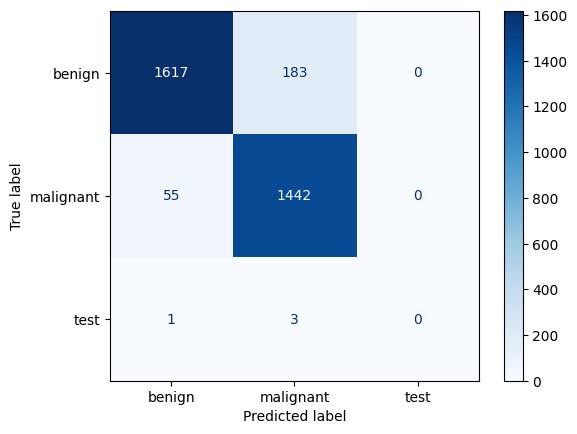

In [26]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🔹 Accuracy مستقیم
accuracy_direct = 100 * correct / total
print(f"Direct Accuracy: {accuracy_direct:.2f}%")

# 🔹 Confusion Matrix
classes = test_loader.dataset.classes   # مطمئن‌ترین راه
cm = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))

# 🔹 Accuracy از روی Confusion Matrix
accuracy_from_cm = 100 * np.trace(cm) / np.sum(cm)
print(f"Accuracy from Confusion Matrix: {accuracy_from_cm:.2f}%")

# 🔹 رسم ماتریس
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.show()

In [27]:
print(f"Class labels: {test_dataset.classes}")

Class labels: ['benign', 'malignant', 'test']


In [28]:
from PIL import Image

# لود کردن یک تصویر جدید
image_path = "C:\\Users\\Asus\\python lab\\skin_cancer\\test\\GettyImages-531536325.jpg" # مسیر تصویر جدید رو اینجا قرار بدید
image = Image.open(image_path)
image = transform(image).unsqueeze(0).to(device)  # تغییر ابعاد تصویر به شکل [1, 3, 224, 224]

# پیش‌بینی دسته‌بندی
output = model(image)
_, predicted_class = output.max(1)
print(f"Predicted class: {test_dataset.classes[predicted_class]}")


Predicted class: malignant
